# NYC Flights 2013 — Data Analysis Pipeline

End-to-end walkthrough of the flight delay analysis project using the `nycflights13` dataset.
This notebook mirrors the four source scripts and can be run top-to-bottom.

---

## Workflow Overview

```
┌──────────────────────────────────────────────────────────────────┐
│                        PIPELINE STAGES                           │
│                                                                  │
│  Stage 1            Stage 2              Stage 3    Stage 4      │
│  DATA ACQUISITION → DATA LOADING    →  ANALYSIS → VISUALISATION │
│  pre_data_          data_loading.py     analysis    visualis-    │
│  loading.py                             .py         ations.py   │
│       │                  │                  │            │       │
│       ▼                  ▼                  ▼            ▼       │
│  data/Raw/*.csv   data/Processed/    Console stats  Graphs/     │
│                   flights.csv                        *.png       │
└──────────────────────────────────────────────────────────────────┘
```

| Stage | Script | Input | Output |
|-------|--------|-------|--------|
| 1. Data Acquisition | `pre_data_loading.py` | GitHub (nycflights13) | `data/Raw/*.csv` |
| 2. Data Loading & Engineering | `data_loading.py` | `data/Raw/*.csv` | `data/Processed/flights.csv` |
| 3. Statistical Analysis | `analysis.py` | `data/Processed/flights.csv` | Console output |
| 4. Visualisation Dashboard | `visualisations.py` | `data/Processed/flights.csv` | 5 PNG charts |

In [3]:
pip install pandas numpy matplotlib seaborn

  Using cached numpy-2.4.4-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ---------------------------------------- 52.8/52.8 kB 2.8 MB/s eta 0:00:00
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/119.8 kB ? eta -:--:--
     -------------------------------------- 119.8/119.8 kB 3.5 MB/s eta 0:00:00
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.4/9.9 MB 11.6 MB/s eta 0:00:01
   --- ------------------------------------ 0.8/9.9 MB 12.5 MB/s eta 0:00:01
   ---- ----------------------------------- 1.2/9.9 MB 10.8 MB/s eta 0:00:01
   ---- ----------------------------------- 1.2/9.9 MB 7.8 MB


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## Setup & Dependencies

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Stage 1 — Data Acquisition (`pre_data_loading.py`)

Downloads the four companion datasets from the tidyverse `nycflights13` GitHub repository
and saves them to `data/Raw/`. Skip if files already exist.

In [5]:
os.makedirs('data/Raw', exist_ok=True)
os.makedirs('data/Processed', exist_ok=True)
os.makedirs('Graphs', exist_ok=True)

base_url = 'https://raw.githubusercontent.com/tidyverse/nycflights13/main/data-raw/'
tables = ['airlines', 'airports', 'weather', 'planes']

for table in tables:
    path = f'data/Raw/{table}.csv'
    if os.path.exists(path):
        print(f'  {table}.csv already exists — skipping download.')
    else:
        df_tmp = pd.read_csv(f'{base_url}{table}.csv')
        df_tmp.to_csv(path, index=False)
        print(f'  Downloaded and saved {table}.csv')

  airlines.csv already exists — skipping download.
  airports.csv already exists — skipping download.
  weather.csv already exists — skipping download.
  planes.csv already exists — skipping download.


---
## Stage 2 — Data Loading & Feature Engineering (`data_loading.py`)

This stage:
1. Loads `data/Raw/flights.csv` (~336 k flight records)
2. **Merges** companion datasets (airlines, airports, weather, planes)
3. **Cleans** data — drops rows missing critical fields, removes duplicates, coerces types
4. **Engineers** new features using NumPy vectorised operations
5. **Exports** the processed dataset to `data/Processed/`

### Engineered features

| Feature | Description |
|---------|-------------|
| `time_of_day` | Morning / Afternoon / Evening / Night |
| `is_delayed_departure` | Boolean — dep_delay > 0 |
| `is_delayed_arrival` | Boolean — arr_delay > 0 |
| `speed` | Average flight speed (mph) |
| `delay_category` | On Time / Minor (0–15 min) / Major (>15 min) |
| `plane_age` | Aircraft age in 2013 (years) |
| `weather_risk` | Normalised 0–1 risk score (wind + visibility) |

In [6]:
# ── Helper: map hour → time-of-day period ─────────────────────────────────────
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'


# ── Merge companion datasets onto flights ─────────────────────────────────────
def merge_companion_data(df):
    airlines = pd.read_csv('data/Raw/airlines.csv')
    airports = pd.read_csv('data/Raw/airports.csv')
    weather  = pd.read_csv('data/Raw/weather.csv')
    planes   = pd.read_csv('data/Raw/planes.csv')

    df = df.merge(airlines, on='carrier', how='left')
    df = df.merge(
        planes[['tailnum', 'year', 'manufacturer', 'model', 'engines', 'engine']],
        on='tailnum', how='left', suffixes=('', '_plane')
    )

    airports_origin = airports[['faa', 'name', 'lat', 'lon', 'tzone']].rename(columns={
        'faa': 'origin', 'name': 'origin_airport_name',
        'lat': 'origin_lat', 'lon': 'origin_lon', 'tzone': 'origin_tzone'
    })
    df = df.merge(airports_origin, on='origin', how='left')

    airports_dest = airports[['faa', 'name', 'lat', 'lon']].rename(columns={
        'faa': 'dest', 'name': 'dest_airport_name',
        'lat': 'dest_lat', 'lon': 'dest_lon'
    })
    df = df.merge(airports_dest, on='dest', how='left')

    weather_cols = ['origin', 'month', 'day', 'hour', 'temp', 'wind_speed', 'precip', 'visib']
    df = df.merge(weather[weather_cols], on=['origin', 'month', 'day', 'hour'], how='left')

    print(f'After merge: {df.shape[0]:,} rows, {df.shape[1]} columns')
    return df


# ── Feature engineering (NumPy vectorised) ────────────────────────────────────
def data_engineering(df):
    df['time_of_day']          = df['hour'].map(get_time_of_day)
    df['is_delayed_departure'] = np.where(df['dep_delay'] > 0, True, False)
    df['is_delayed_arrival']   = np.where(df['arr_delay'] > 0, True, False)
    df['speed']                = np.round(df['distance'] / (df['air_time'] / 60), 2)
    df['delay_category']       = pd.cut(
        df['dep_delay'],
        bins=[-float('inf'), 0, 15, float('inf')],
        labels=['On Time', 'Minor', 'Major']
    )
    df['plane_age'] = np.where(
        df['year_plane'].notna(), 2013 - df['year_plane'], np.nan
    )
    if 'wind_speed' in df.columns and 'visib' in df.columns:
        wind_norm  = np.clip(df['wind_speed'].fillna(0) / 50, 0, 1)
        visib_norm = np.clip(1 - (df['visib'].fillna(10) / 10), 0, 1)
        df['weather_risk'] = np.round((wind_norm + visib_norm) / 2, 3)
    return df


print('Pipeline functions defined.')

Pipeline functions defined.


In [7]:
# ── Run the full data pipeline ────────────────────────────────────────────────
raw = pd.read_csv('data/Raw/flights.csv')
original_len = len(raw)
print(f'Loaded {original_len:,} raw flight records with {raw.shape[1]} columns.')

df = merge_companion_data(raw)

# Clean
df = df.dropna(subset=['dep_time', 'arr_time', 'carrier', 'origin', 'dest'])
df = df.drop_duplicates().reset_index(drop=True)
print(f'After cleaning: {len(df):,} rows ({round(len(df)/original_len*100, 2)}% retained)')

numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
for col in ['carrier', 'origin', 'dest']:
    df[col] = df[col].str.strip()

df = data_engineering(df)

# Drop helper columns before saving
cols_to_drop = [
    'sched_dep_time', 'sched_arr_time', 'flight', 'minute',
    'year_plane', 'engines', 'model',
    'origin_airport_name', 'origin_lat', 'origin_lon', 'origin_tzone',
    'dest_airport_name', 'dest_lat', 'dest_lon',
    'temp', 'precip'
]
df = df.drop(columns=cols_to_drop, errors='ignore')

df.to_csv('data/Processed/flights.csv', index=False)
df.to_json('data/Processed/flights.json', orient='split', index=True)
print(f'Saved → data/Processed/flights.csv  ({df.shape[0]:,} rows, {df.shape[1]} columns)')

Loaded 336,776 raw flight records with 21 columns.
After merge: 336,776 rows, 38 columns
After cleaning: 328,063 rows (97.41% retained)
Saved → data/Processed/flights.csv  (328,063 rows, 29 columns)


In [8]:
# Preview the processed dataset
print('Columns:', df.columns.tolist())
df.head()

Columns: ['id', 'year', 'month', 'day', 'dep_time', 'dep_delay', 'arr_time', 'arr_delay', 'carrier', 'tailnum', 'origin', 'dest', 'air_time', 'distance', 'hour', 'time_hour', 'name_x', 'name_y', 'manufacturer', 'engine', 'wind_speed', 'visib', 'time_of_day', 'is_delayed_departure', 'is_delayed_arrival', 'speed', 'delay_category', 'plane_age', 'weather_risk']


,id,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,...,engine,wind_speed,visib,time_of_day,is_delayed_departure,is_delayed_arrival,speed,delay_category,plane_age,weather_risk
0,0,2013,1,1,517.0,2.0,830.0,11.0,UA,N14228,...,Turbo-fan,12.65858,10.0,Morning,True,True,370.04,Minor,14.0,0.127
1,1,2013,1,1,533.0,4.0,850.0,20.0,UA,N24211,...,Turbo-fan,14.96014,10.0,Morning,True,True,374.27,Minor,15.0,0.150
2,2,2013,1,1,542.0,2.0,923.0,33.0,AA,N619AA,...,Turbo-fan,14.96014,10.0,Morning,True,True,408.38,Minor,23.0,0.150
3,3,2013,1,1,544.0,-1.0,1004.0,-18.0,B6,N804JB,...,Turbo-fan,14.96014,10.0,Morning,False,False,516.72,On Time,1.0,0.150
4,4,2013,1,1,554.0,-6.0,812.0,-25.0,DL,N668DN,...,Turbo-fan,16.11092,10.0,Morning,False,False,394.14,On Time,22.0,0.161


In [9]:
# Null counts and data types
pd.DataFrame({
    'dtype':      df.dtypes,
    'null_count': df.isnull().sum(),
    'null_pct':   round(df.isnull().sum() / len(df) * 100, 2)
})

,dtype,null_count,null_pct
id,int64,0,0.00
year,int64,0,0.00
month,int64,0,0.00
day,int64,0,0.00
dep_time,float64,0,0.00
dep_delay,float64,0,0.00
arr_time,float64,0,0.00
arr_delay,float64,717,0.22
carrier,str,0,0.00
tailnum,str,0,0.00


---
## Stage 3 — Statistical Analysis (`analysis.py`)

Descriptive statistics, percentile breakdowns, carrier/airport comparisons,
time-of-day patterns, and outlier detection — all computed with NumPy.

In [10]:
# Load processed data (re-run this if you skipped Stage 2)
df = pd.read_csv('data/Processed/flights.csv')
print(f'Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset: 328,063 rows × 29 columns


In [11]:
# ── 1. Descriptive Statistics ─────────────────────────────────────────────────
def summarise_column(arr, label):
    arr = arr[~np.isnan(arr)]
    print(f'  {label}')
    print(f'    Mean:       {np.mean(arr):.2f}')
    print(f'    Median:     {np.median(arr):.2f}')
    print(f'    Std Dev:    {np.std(arr):.2f}')
    print(f'    Variance:   {np.var(arr):.2f}')
    print(f'    Min:        {np.min(arr):.2f}')
    print(f'    Max:        {np.max(arr):.2f}')
    print()

print('1. Descriptive Stats (NumPy)\n')
numeric_summary = {
    'Departure Delay (mins)': df['dep_delay'].values,
    'Arrival Delay (mins)':   df['arr_delay'].values,
    'Air Time (mins)':        df['air_time'].values,
    'Distance (miles)':       df['distance'].values,
    'Speed (mph)':            df['speed'].values,
}
for label, arr in numeric_summary.items():
    summarise_column(arr, label)

1. Descriptive Stats (NumPy)

  Departure Delay (mins)
    Mean:       12.58
    Median:     -2.00
    Std Dev:    40.09
    Variance:   1606.95
    Min:        -43.00
    Max:        1301.00

  Arrival Delay (mins)
    Mean:       6.90
    Median:     -5.00
    Std Dev:    44.63
    Variance:   1992.12
    Min:        -86.00
    Max:        1272.00

  Air Time (mins)
    Mean:       150.69
    Median:     129.00
    Std Dev:    93.69
    Variance:   8777.47
    Min:        20.00
    Max:        695.00

  Distance (miles)
    Mean:       1048.83
    Median:     888.00
    Std Dev:    735.96
    Variance:   541634.23
    Min:        80.00
    Max:        4983.00

  Speed (mph)
    Mean:       394.27
    Median:     404.15
    Std Dev:    60.63
    Variance:   3676.35
    Min:        76.80
    Max:        703.38



In [12]:
# ── 2. Percentile Breakdown ───────────────────────────────────────────────────
print('2. Percentile Breakdown — Departure / Arrival Delays\n')
dep_delay = df['dep_delay'].dropna().values
arr_delay = df['arr_delay'].dropna().values

print(f"  {'Percentile':<15} {'Dep Delay (mins)':>20} {'Arr Delay (mins)':>20}")
print(f"  {'-'*60}")
for p in [10, 25, 50, 75, 90, 95, 99]:
    d = np.percentile(dep_delay, p)
    a = np.percentile(arr_delay, p)
    print(f'  {p}th{"":<11} {d:>20.2f} {a:>20.2f}')

dep_iqr = np.percentile(dep_delay, 75) - np.percentile(dep_delay, 25)
arr_iqr = np.percentile(arr_delay, 75) - np.percentile(arr_delay, 25)
print(f'\n  IQR (Dep Delay):  {dep_iqr:.2f} mins')
print(f'  IQR (Arr Delay):  {arr_iqr:.2f} mins')

2. Percentile Breakdown — Departure / Arrival Delays

  Percentile          Dep Delay (mins)     Arr Delay (mins)
  ------------------------------------------------------------
  10th                           -7.00               -26.00
  25th                           -5.00               -17.00
  50th                           -2.00                -5.00
  75th                           11.00                14.00
  90th                           49.00                52.00
  95th                           88.00                91.00
  99th                          191.00               190.00

  IQR (Dep Delay):  16.00 mins
  IQR (Arr Delay):  31.00 mins


In [13]:
# ── 3. Mean Departure Delay by Carrier ───────────────────────────────────────
print('3. Mean Departure Delay by Carrier\n')
for c in sorted(df['carrier'].unique()):
    delays = df[df['carrier'] == c]['dep_delay'].dropna().values
    print(f'  {c}   Mean: {np.mean(delays):>6.2f} min   Std Dev: {np.std(delays):.2f}')

3. Mean Departure Delay by Carrier

  9E   Mean:  16.48 min   Std Dev: 45.52
  AA   Mean:   8.57 min   Std Dev: 37.35
  AS   Mean:   5.80 min   Std Dev: 31.34
  B6   Mean:  12.99 min   Std Dev: 38.42
  DL   Mean:   9.25 min   Std Dev: 39.71
  EV   Mean:  19.86 min   Std Dev: 46.44
  F9   Mean:  20.20 min   Std Dev: 58.36
  FL   Mean:  18.60 min   Std Dev: 52.44
  HA   Mean:   4.90 min   Std Dev: 74.00
  MQ   Mean:  10.47 min   Std Dev: 39.06
  OO   Mean:  12.59 min   Std Dev: 42.32
  UA   Mean:  12.03 min   Std Dev: 35.55
  US   Mean:   3.77 min   Std Dev: 28.03
  VX   Mean:  12.76 min   Std Dev: 43.98
  WN   Mean:  17.69 min   Std Dev: 43.26
  YV   Mean:  18.90 min   Std Dev: 49.12


In [14]:
# ── 4. Departure Delay Stats by Airport ──────────────────────────────────────
print('4. Departure Delay Stats by Airport\n')
for origin in df['origin'].unique():
    delays = df[df['origin'] == origin]['dep_delay'].dropna().values
    print(f'  {origin}')
    print(f'    Mean:            {np.mean(delays):.2f}')
    print(f'    Median:          {np.median(delays):.2f}')
    print(f'    Std Dev:         {np.std(delays):.2f}')
    print(f'    95th percentile: {np.percentile(delays, 95):.2f}')
    print()

4. Departure Delay Stats by Airport

  EWR
    Mean:            15.04
    Median:          -1.00
    Std Dev:         41.20
    95th percentile: 95.00

  LGA
    Mean:            10.30
    Median:          -3.00
    Std Dev:         39.92
    95th percentile: 81.00

  JFK
    Mean:            12.04
    Median:          -1.00
    Std Dev:         38.86
    95th percentile: 84.00



In [15]:
# ── 5. Delay Rates by Time of Day ─────────────────────────────────────────────
print('5. Delay Rates by Time of Day\n')
for t in ['Morning', 'Afternoon', 'Evening', 'Night']:
    subset  = df[df['time_of_day'] == t]
    total   = len(subset)
    delayed = int(np.sum(subset['is_delayed_departure'].values))
    rate    = round((delayed / total) * 100, 1)
    mean_d  = round(np.mean(subset['dep_delay'].dropna().values), 2)
    print(f'  {t:<12}  Total: {total:>6,}  Delayed: {delayed:>6,}  Rate: {rate:>5}%  Mean delay: {mean_d:>6} min')

5. Delay Rates by Time of Day

  Morning       Total: 128,827  Delayed: 32,995  Rate:  25.6%  Mean delay:   3.92 min
  Afternoon     Total: 103,638  Delayed: 45,759  Rate:  44.2%  Mean delay:  14.13 min
  Evening       Total: 81,477  Delayed: 42,134  Rate:  51.7%  Mean delay:  22.58 min
  Night         Total: 14,121  Delayed:  7,233  Rate:  51.2%  Mean delay:  22.45 min


In [16]:
# ── 6. Outlier Detection — IQR Method ────────────────────────────────────────
print('6. Outlier Detection — Departure Delay (IQR Method)\n')
q1    = np.percentile(dep_delay, 25)
q3    = np.percentile(dep_delay, 75)
iqr   = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = dep_delay[(dep_delay < lower) | (dep_delay > upper)]

print(f'  Q1:               {q1:.2f} min')
print(f'  Q3:               {q3:.2f} min')
print(f'  IQR:              {iqr:.2f} min')
print(f'  Lower bound:      {lower:.2f} min')
print(f'  Upper bound:      {upper:.2f} min')
print(f'  Outlier count:    {len(outliers):,}')
print(f'  Outlier pct:      {round(len(outliers)/len(dep_delay)*100, 2)}%')
print(f'  Worst delay:      {np.max(outliers):.0f} min  ({np.max(outliers)/60:.1f} hrs)')

6. Outlier Detection — Departure Delay (IQR Method)

  Q1:               -5.00 min
  Q3:               11.00 min
  IQR:              16.00 min
  Lower bound:      -29.00 min
  Upper bound:      35.00 min
  Outlier count:    43,012
  Outlier pct:      13.11%
  Worst delay:      1301 min  (21.7 hrs)


---
## Stage 4 — Visualisation Dashboard (`visualisations.py`)

All five charts displayed together in a single dashboard grid, then individually at full resolution.

| # | Chart | Type | Insight |
|---|-------|------|---------|
| 1 | Average Delay per Carrier | Bar chart | Which airlines run latest |
| 2 | Delay Distribution by Airline | Boxplot | Spread and consistency per carrier |
| 3 | Avg Delay by Hour × Month | Heatmap | Seasonal and daily patterns |
| 4 | Flight Distance vs Arrival Delay | Scatter | Distance–delay correlation |
| 5 | Top 10 Busiest Routes | Bar chart | Network traffic concentration |

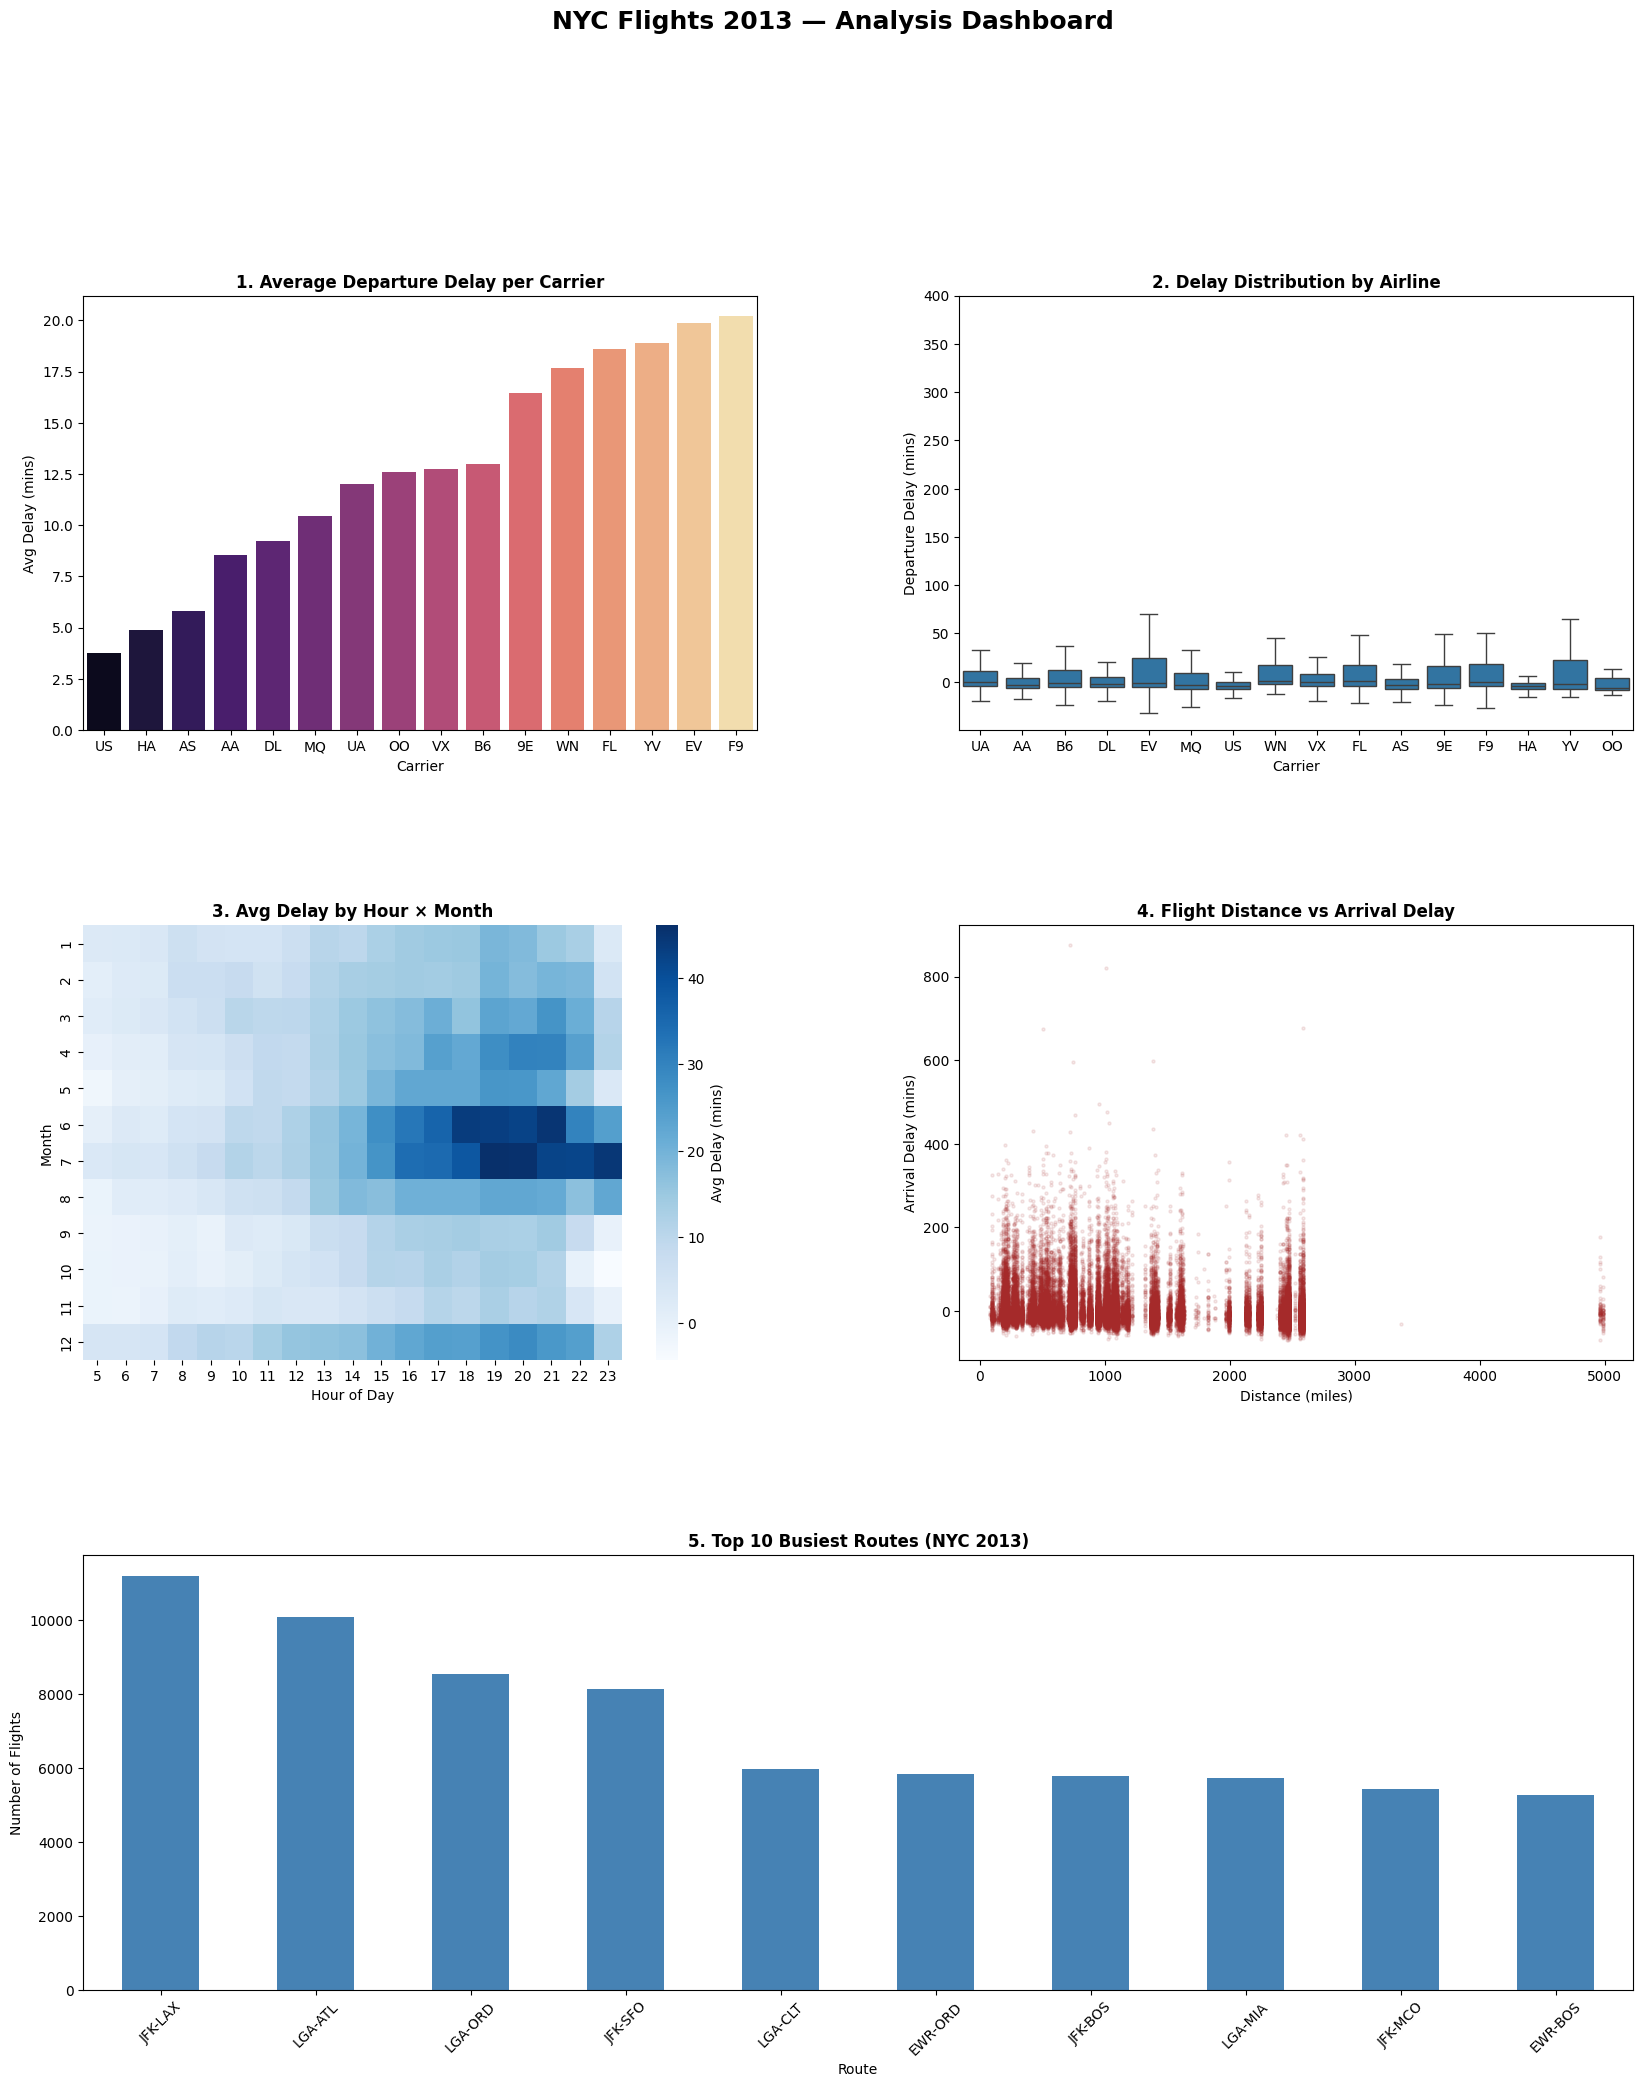

Dashboard saved → Graphs/dashboard.png


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
#  DASHBOARD — all 5 charts in one figure
# ═══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd 

df = pd.read_csv('data/Processed/flights.csv')
fig = plt.figure(figsize=(20, 22))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

# ── Chart 1: Average Delay per Carrier ───────────────────────────────────────

ax1 = fig.add_subplot(gs[0, 0])
avg_delay = df.groupby('carrier')['dep_delay'].mean().sort_values()
sns.barplot(x=avg_delay.index, y=avg_delay.values,
            hue=avg_delay.index, palette='magma', legend=False, ax=ax1)
ax1.set_title('1. Average Departure Delay per Carrier', fontweight='bold')
ax1.set_xlabel('Carrier')
ax1.set_ylabel('Avg Delay (mins)')

# ── Chart 2: Delay Distribution by Carrier ───────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
sns.boxplot(data=df, x='carrier', y='dep_delay', showfliers=False, ax=ax2)
ax2.set_ylim(-50, 400)
ax2.set_yticks(range(0, 401, 50))
ax2.set_title('2. Delay Distribution by Airline', fontweight='bold')
ax2.set_xlabel('Carrier')
ax2.set_ylabel('Departure Delay (mins)')

# ── Chart 3: Heatmap — Avg Delay by Hour × Month ─────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
pivot = df.pivot_table(index='month', columns='hour', values='dep_delay', aggfunc='mean')
sns.heatmap(pivot, cmap='Blues', ax=ax3, cbar_kws={'label': 'Avg Delay (mins)'})
ax3.set_title('3. Avg Delay by Hour × Month', fontweight='bold')
ax3.set_xlabel('Hour of Day')
ax3.set_ylabel('Month')

# ── Chart 4: Distance vs Arrival Delay ───────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
sample = df.dropna(subset=['distance', 'arr_delay']).sample(
    n=min(50_000, len(df)), random_state=42
)
ax4.scatter(sample['distance'], sample['arr_delay'], alpha=0.1, color='brown', s=5)
ax4.set_title('4. Flight Distance vs Arrival Delay', fontweight='bold')
ax4.set_xlabel('Distance (miles)')
ax4.set_ylabel('Arrival Delay (mins)')

# ── Chart 5: Top 10 Busiest Routes (full width) ───────────────────────────────
ax5  = fig.add_subplot(gs[2, :])
df['route'] = df['origin'] + '-' + df['dest']
top_routes  = df['route'].value_counts().head(10)
top_routes.plot(kind='bar', color='steelblue', ax=ax5)
ax5.set_title('5. Top 10 Busiest Routes (NYC 2013)', fontweight='bold')
ax5.set_ylabel('Number of Flights')
ax5.set_xlabel('Route')
ax5.tick_params(axis='x', rotation=45)

fig.suptitle('NYC Flights 2013 — Analysis Dashboard',
             fontsize=18, fontweight='bold', y=1.01)

plt.savefig('Graphs/dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print('Dashboard saved → Graphs/dashboard.png')

---
### Individual Charts — Full Resolution

In [ ]:
# Chart 1: Average Delay per Carrier
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd 

df = pd.read_csv('data/Processed/flights.csv')
fig, ax = plt.subplots(figsize=(12, 6))
avg_delay = df.groupby('carrier')['dep_delay'].mean().sort_values()
sns.barplot(x=avg_delay.index, y=avg_delay.values,
            hue=avg_delay.index, palette='magma', legend=False, ax=ax)
ax.set_title('Average Departure Delay per Carrier', fontsize=14, fontweight='bold')
ax.set_xlabel('Carrier')
ax.set_ylabel('Avg Delay (mins)')
plt.savefig('Graphs/Avg_Carrier_Delays.png', bbox_inches='tight')
plt.show()

NameError: name 'plt' is not defined

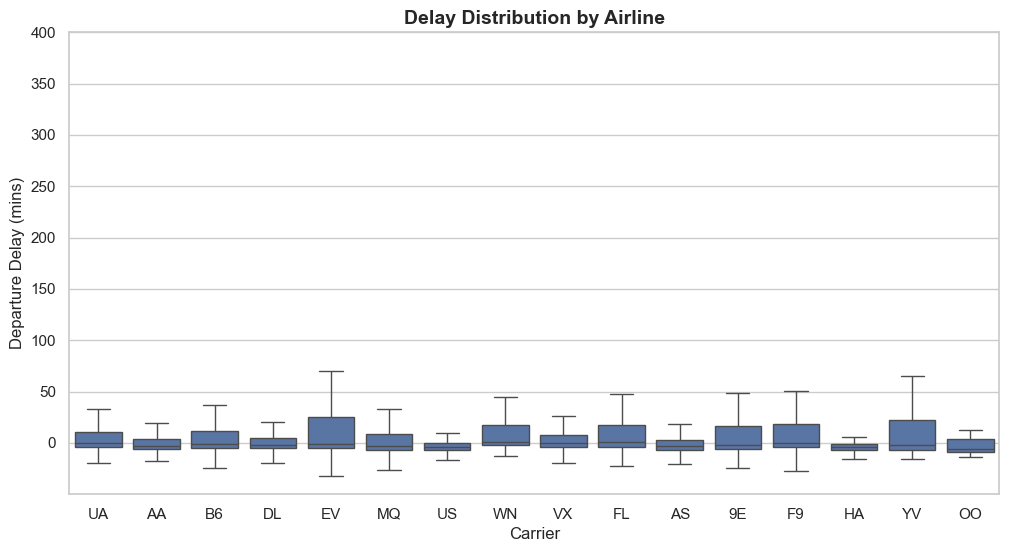

In [ ]:
# Chart 2: Delay Distribution by Airline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd 

df = pd.read_csv('data/Processed/flights.csv')
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x='carrier', y='dep_delay', showfliers=False, ax=ax)
ax.set_ylim(-50, 400)
ax.set_yticks(range(0, 401, 50))
ax.set_title('Delay Distribution by Airline', fontsize=14, fontweight='bold')
ax.set_xlabel('Carrier')
ax.set_ylabel('Departure Delay (mins)')
plt.savefig('Graphs/Carrier_Delay_Distribution.png', bbox_inches='tight')
plt.show()

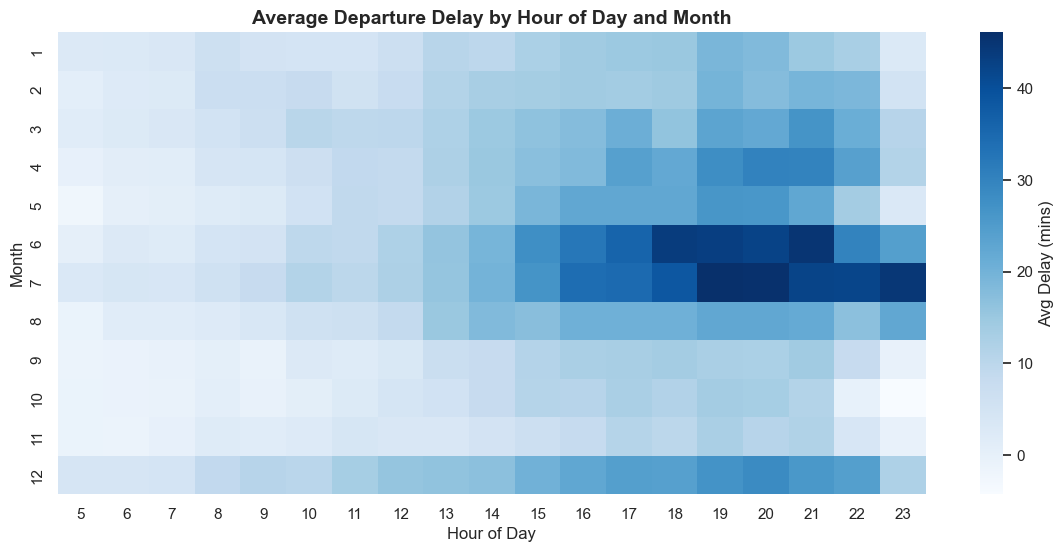

In [ ]:
# Chart 3: Delay Heatmap — Hour × Month
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd 

df = pd.read_csv('data/Processed/flights.csv')
fig, ax = plt.subplots(figsize=(14, 6))
pivot = df.pivot_table(index='month', columns='hour', values='dep_delay', aggfunc='mean')
sns.heatmap(pivot, cmap='Blues', ax=ax, cbar_kws={'label': 'Avg Delay (mins)'})
ax.set_title('Average Departure Delay by Hour of Day and Month',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Month')
plt.savefig('Graphs/Delay_Using_A_Heatmap.png', bbox_inches='tight')
plt.show()

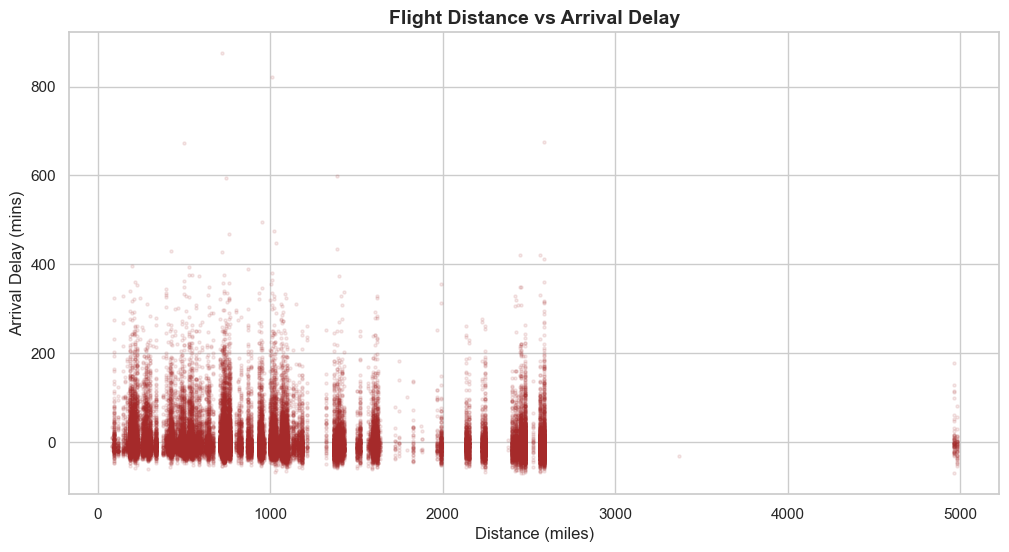

In [ ]:
# Chart 4: Flight Distance vs Arrival Delay
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd 

df = pd.read_csv('data/Processed/flights.csv')
fig, ax = plt.subplots(figsize=(12, 6))
sample = df.dropna(subset=['distance', 'arr_delay']).sample(
    n=min(50_000, len(df)), random_state=42
)
ax.scatter(sample['distance'], sample['arr_delay'], alpha=0.1, color='brown', s=5)
ax.set_title('Flight Distance vs Arrival Delay', fontsize=14, fontweight='bold')
ax.set_xlabel('Distance (miles)')
ax.set_ylabel('Arrival Delay (mins)')
plt.savefig('Graphs/FlightDistance vs FlightDelay.png', bbox_inches='tight')
plt.show()

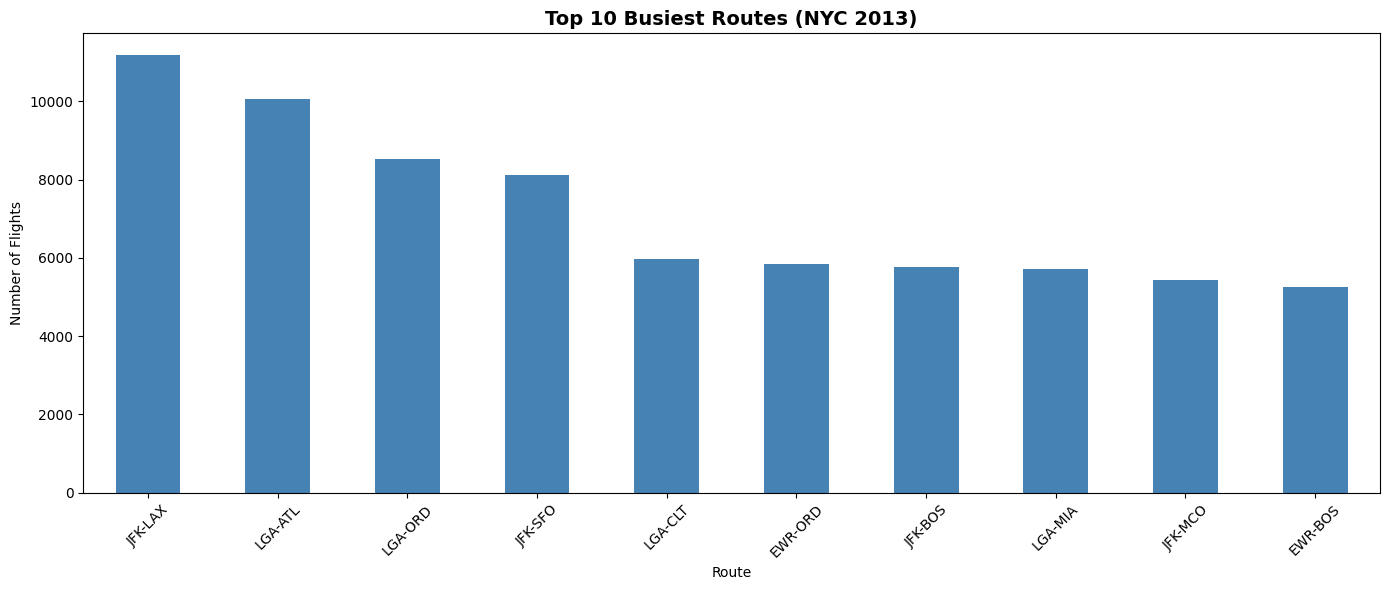

In [7]:
# Chart 5: Top 10 Busiest Routes
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd 

df = pd.read_csv('data/Processed/flights.csv')
df['route'] = df['origin'] + '-' + df['dest']
top_routes  = df['route'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(14, 6))
top_routes.plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Top 10 Busiest Routes (NYC 2013)', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Flights')
ax.set_xlabel('Route')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('Graphs/Top_Ten_Routes.png', bbox_inches='tight')
plt.show()